<img src="image_filename.png" width="">

## Company Background

Airbnb is a modern company operating in the hospitality industry through an innovative, platform-based business model. Instead of owning hotels, Airbnb collaborates with homeowners who list their properties for short-term rentals.

Homeowners can register and publish their property listings on the platform, making them available to travelers seeking accommodation. Users can browse these listings and make bookings directly through the Airbnb application.

Today, Airbnb operates globally, connecting millions of hosts and guests across various countries. The platform makes it easy for travelers to find accommodation based on their budget, preferred design, and the surrounding environment of the location they choose.

## Stakeholder Segment

**Primary Stakeholder: Revenue Management / Pricing Team (Airbnb Bangkok, Thailand)**  

This team focuses on optimizing pricing strategies to maximize booking performance across the platform.

**How this analysis supports them:**
- Identify high-performing price and room type segments  
- Provide data-driven pricing recommendations for hosts  
- Highlight top-performing neighbourhood combinations  
- Enable better in-app suggestions and targeted marketing campaigns

## Problem Statement

Airbnb wants to **understand what drives listing performance in Bangkok** specifically how price, location, and room type influence demand.

As a *data analyst*, we aim to answer two key business questions:

- **Q1. Which price and room type segments should Airbnb prioritize to maximize overall demand?**
- **Q2. Which price, neighbourhood, and room type combinations deliver the most consistent bookings, and how can pricing guide hosts toward them?**

## Dataset

This analysis uses Airbnb listing data from Bangkok, Thailand. The dataset can be accessed [here](https://drive.google.com/drive/folders/1A_KBMRFTS5Mthpp46nulso679ML4ZwTF?usp=sharing).

| Column | Description |
|---|---|
| `id` | Unique listing identifier |
| `host_id` | Unique host identifier |
| `neighbourhood` | Bangkok district where the listing is located |
| `latitude` / `longitude` | Geographic coordinates |
| `room_type` | Entire home/apt, Private room, Hotel room, or Shared room |
| `price` | Nightly price in THB |
| `minimum_nights` | Minimum nights required per booking |
| `number_of_reviews` | Total reviews received |
| `last_review` | Date of most recent review |
| `reviews_per_month` | Average monthly review rate |
| `calculated_host_listings_count` | Number of listings the host owns |
| `availability_365` | Days available per year |
| `number_of_reviews_ltm` | Reviews in the last 12 months |

In [1]:
## Setup
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
from IPython.display import display, Markdown

# Show full content
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
# Load dataset
df = pd.read_csv('Airbnb Listings Bangkok.csv')

display(df.head(3), df.tail(3))

,Unnamed: 0,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,0,27934,Nice room with superb city view,120437,Nuttee,Ratchathewi,13.75983,100.54134,Entire home/apt,1905,3,65,2020-01-06,0.5,2,353,0
1,1,27979,"Easy going landlord,easy place",120541,Emy,Bang Na,13.66818,100.61674,Private room,1316,1,0,NaN,NaN,2,358,0
2,2,28745,modern-style apartment in Bangkok,123784,Familyroom,Bang Kapi,13.75232,100.62402,Private room,800,60,0,NaN,NaN,1,365,0


,Unnamed: 0,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
15851,15851,790475335086864240,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.753169,100.538700,Private room,1214,1,0,NaN,NaN,14,365,0
15852,15852,790475546213717328,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.754789,100.538757,Private room,1214,1,0,NaN,NaN,14,365,0
15853,15853,790476492384199044,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.752960,100.540820,Private room,1214,1,0,NaN,NaN,14,365,0


## Data Understanding

Before cleaning, we explore the dataset structure to identify any issues that need to be addressed.

In [3]:
# Dataset shape
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')

Rows: 15,854
Columns: 17


In [4]:
# Dataset column info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15854 entries, 0 to 15853
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      15854 non-null  int64  
 1   id                              15854 non-null  int64  
 2   name                            15846 non-null  object 
 3   host_id                         15854 non-null  int64  
 4   host_name                       15853 non-null  object 
 5   neighbourhood                   15854 non-null  object 
 6   latitude                        15854 non-null  float64
 7   longitude                       15854 non-null  float64
 8   room_type                       15854 non-null  object 
 9   price                           15854 non-null  int64  
 10  minimum_nights                  15854 non-null  int64  
 11  number_of_reviews               15854 non-null  int64  
 12  last_review                     

In [5]:
# Summary statistics (Numeric)
df.describe().round(2)

,Unnamed: 0,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,15854.00,1.585400e+04,1.585400e+04,15854.00,15854.00,15854.00,15854.00,15854.00,10064.00,15854.00,15854.00,15854.00
mean,7926.50,1.579397e+17,1.541058e+08,13.75,100.56,3217.70,15.29,16.65,0.81,13.89,244.38,3.48
std,4576.80,2.946015e+17,1.318726e+08,0.04,0.05,24972.12,50.82,40.61,1.09,30.27,125.84,8.92
min,0.00,2.793400e+04,5.892000e+04,13.53,100.33,0.00,1.00,0.00,0.01,1.00,0.00,0.00
25%,3963.25,2.104509e+07,3.974431e+07,13.72,100.53,900.00,1.00,0.00,0.12,1.00,138.00,0.00
50%,7926.50,3.503734e+07,1.224556e+08,13.74,100.56,1429.00,1.00,2.00,0.44,4.00,309.00,0.00
75%,11889.75,5.256154e+07,2.390547e+08,13.76,100.59,2429.00,7.00,13.00,1.06,13.00,360.00,3.00
max,15853.00,7.908162e+17,4.926659e+08,13.95,100.92,1100000.00,1125.00,1224.00,19.13,228.00,365.00,325.00


In [6]:
# Summary statistics (Text)
df.describe(include='object')

,name,host_name,neighbourhood,room_type,last_review
count,15846,15853,15854,15854,10064
unique,14794,5312,50,4,1669
top,New! La Chada Night Market studio 2PPL near MRT,Curry,Vadhana,Entire home/apt,2022-12-11
freq,45,228,2153,8912,189


In [7]:
# Unique values per column
summary = pd.DataFrame([
    {'Column': col, 'Unique Values': df[col].nunique(), 
     'Sample': list(df[col].dropna().unique()[:5])}
    for col in df.columns
])
summary

,Column,Unique Values,Sample
0,Unnamed: 0,15854,"[0, 1, 2, 3, 4]"
1,id,15854,"[27934, 27979, 28745, 35780, 941865]"
2,name,14794,"[Nice room with superb city view, Easy going landlord,easy place, modern-style apartment in Bangkok, Spacious one bedroom at The Kris Condo Bldg. 3, Suite Room 3 at MetroPoint]"
3,host_id,6659,"[120437, 120541, 123784, 153730, 610315]"
4,host_name,5312,"[Nuttee, Emy, Familyroom, Sirilak, Kasem]"
5,neighbourhood,50,"[Ratchathewi, Bang Na, Bang Kapi, Din Daeng, Bang Kho laen]"
6,latitude,9606,"[13.75983, 13.66818, 13.75232, 13.78823, 13.76872]"
7,longitude,10224,"[100.54134, 100.61674, 100.62402, 100.57256, 100.63338]"
8,room_type,4,"[Entire home/apt, Private room, Hotel room, Shared room]"
9,price,3040,"[1905, 1316, 800, 1286, 1000]"


**Key observations**

In general, we can observe that:

1. Dataset has 15,854 rows and 17 columns; missing values mainly in `last_review` and `reviews_per_month` (~36%), indicating low/no activity listings.

2. `last_review` is in object format and should be converted to datetime for time-based analysis.

3. ID columns (`id`, `host_id`, `Unnamed: 0`) are not useful for analysis or modeling.

4. Location features (`latitude`, `longitude`, `neighbourhood`) are complete and useful for spatial insights.

5. `price` is numeric but likely skewed, requiring outlier handling or transformation.

6. Review metrics (`number_of_reviews`, etc.) indicate demand and listing performance.

7. `room_type`, `minimum_nights`, and `availability_365` reflect pricing and booking strategy.

## Data Cleaning

We identified initial data issues. Next, we will clean and handle them step by step before analysis.

#### Step 1 — Check for duplicates

Every listing should have a unique `id`. We check for full row duplicates and duplicate listing IDs.

In [8]:
# Full row duplicates
print("Duplicate rows:", df.duplicated().sum())

# Duplicate listing IDs
print("Duplicate listing IDs:", df["id"].duplicated().sum())

Duplicate rows: 0
Duplicate listing IDs: 0


From the results, no duplicate rows or duplicated `id` values were found, indicating the dataset is clean in this aspect.

#### Step 2 — Remove irrelevant columns

Some columns have no analytical value for our business questions and can be dropped:

- `Unnamed: 0`: Redundant index from data export  
- `name`: Too unstructured for meaningful aggregation  
- `host_name`: Not relevant to pricing or demand patterns  

In [9]:
# Drop columns not needed for analysis
df = df.drop(columns=['Unnamed: 0', 'name', 'host_name'])

print('Remaining columns:', df.shape[1])

Remaining columns: 14


In [10]:
columns_df = pd.DataFrame(df.columns, columns=['column_name'])
columns_df

,column_name
0,id
1,host_id
2,neighbourhood
3,latitude
4,longitude
5,room_type
6,price
7,minimum_nights
8,number_of_reviews
9,last_review


#### Step 3 — Handle missing values

Handle missing values to avoid errors and bias in analysis:

- Check missing values  
- Decide how to handle them  
- Apply appropriate treatment  

In [11]:
# Missing value summary
df_null = pd.DataFrame({
    'Null Count': df.isna().sum(),
    'Null Percentage': (df.isna().sum() / len(df) * 100).round(2)
})

df_null

,Null Count,Null Percentage
id,0,0.00
host_id,0,0.00
neighbourhood,0,0.00
latitude,0,0.00
longitude,0,0.00
room_type,0,0.00
price,0,0.00
minimum_nights,0,0.00
number_of_reviews,0,0.00
last_review,5790,36.52


<h3 style='text-align:center;'>Column: price</h3>

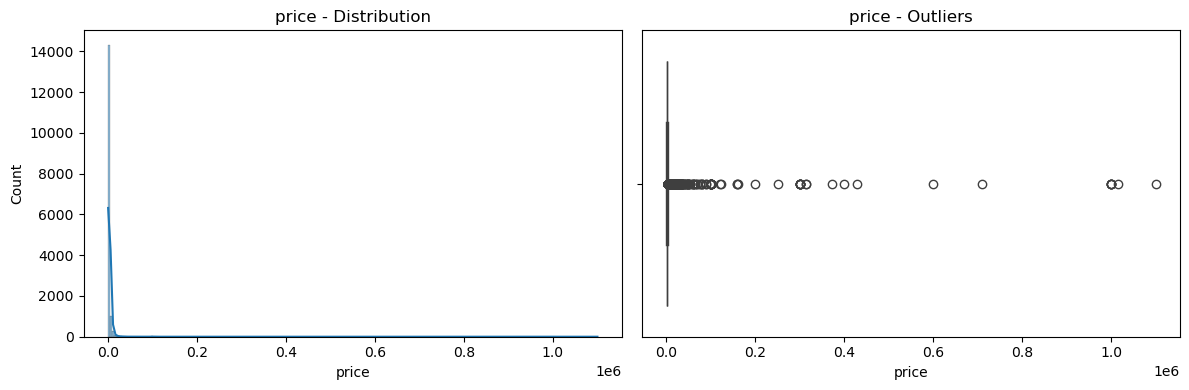

<h3 style='text-align:center;'>Column: minimum_nights</h3>

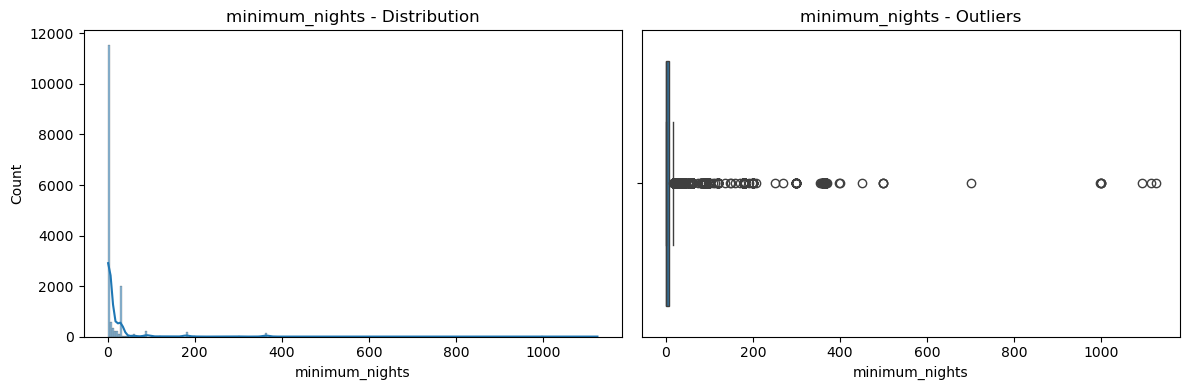

<h3 style='text-align:center;'>Column: number_of_reviews</h3>

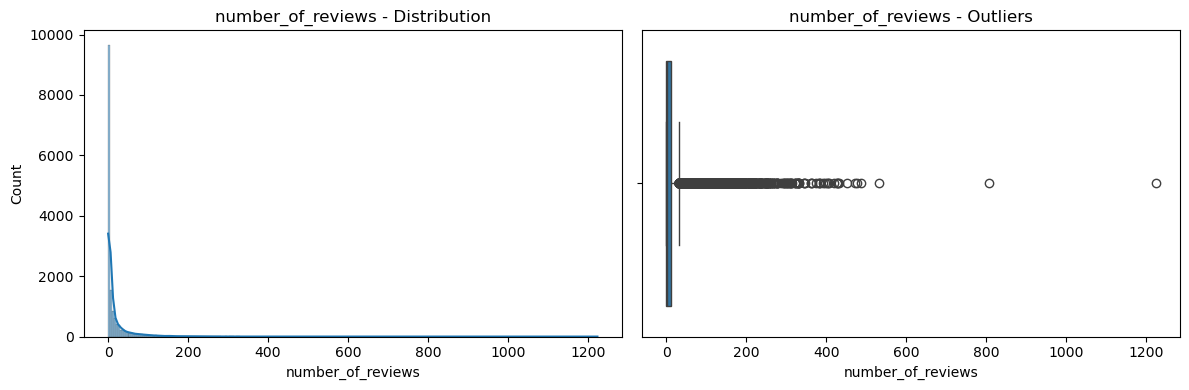

<h3 style='text-align:center;'>Column: reviews_per_month</h3>

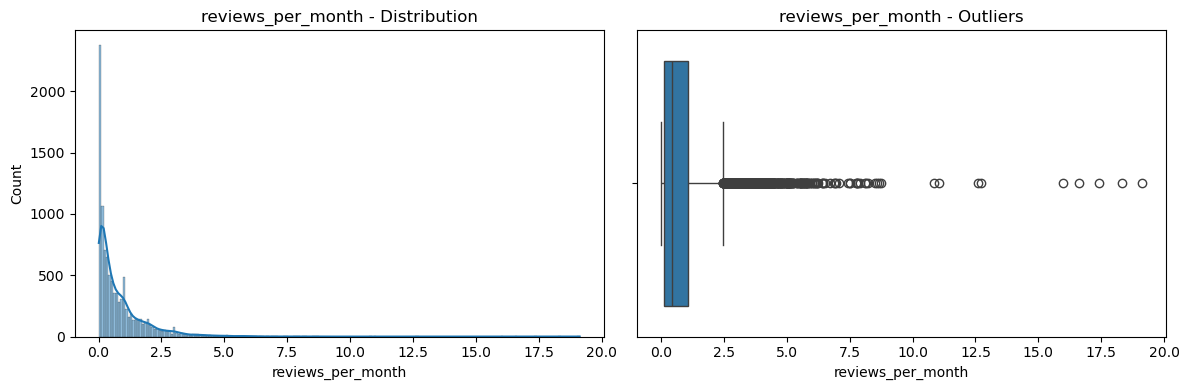

<h3 style='text-align:center;'>Column: calculated_host_listings_count</h3>

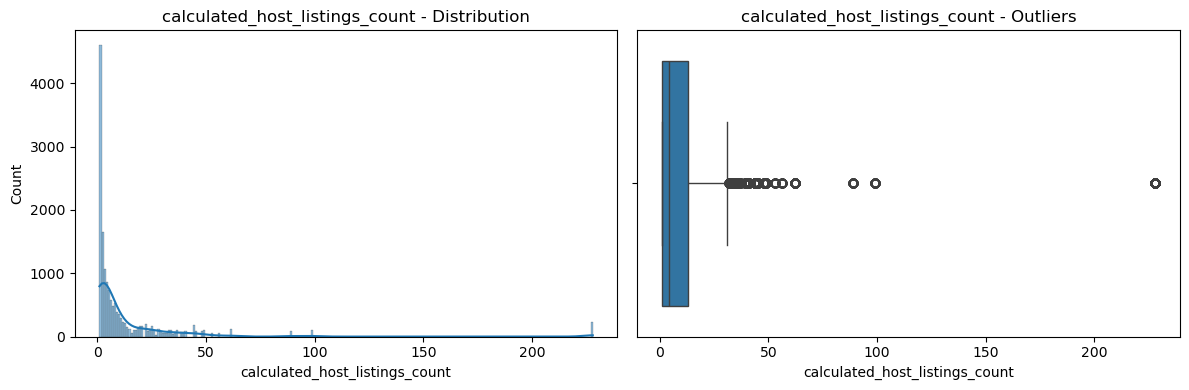

<h3 style='text-align:center;'>Column: availability_365</h3>

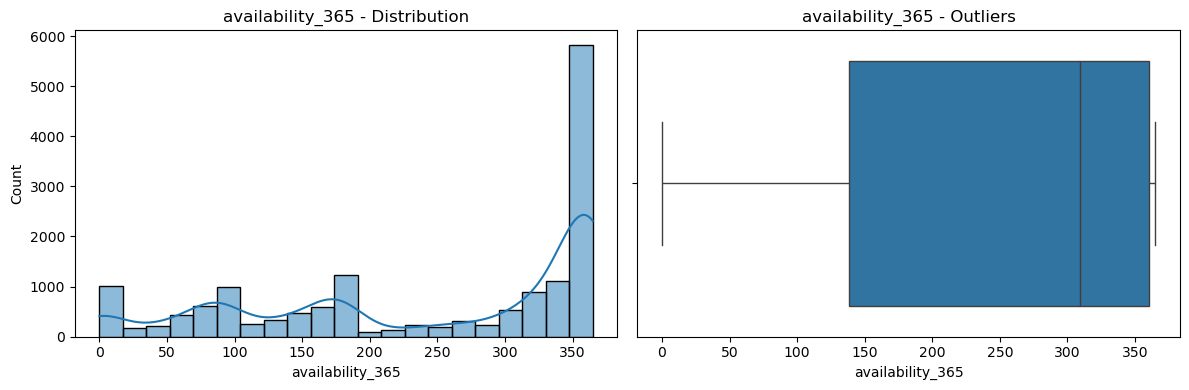

<h3 style='text-align:center;'>Column: number_of_reviews_ltm</h3>

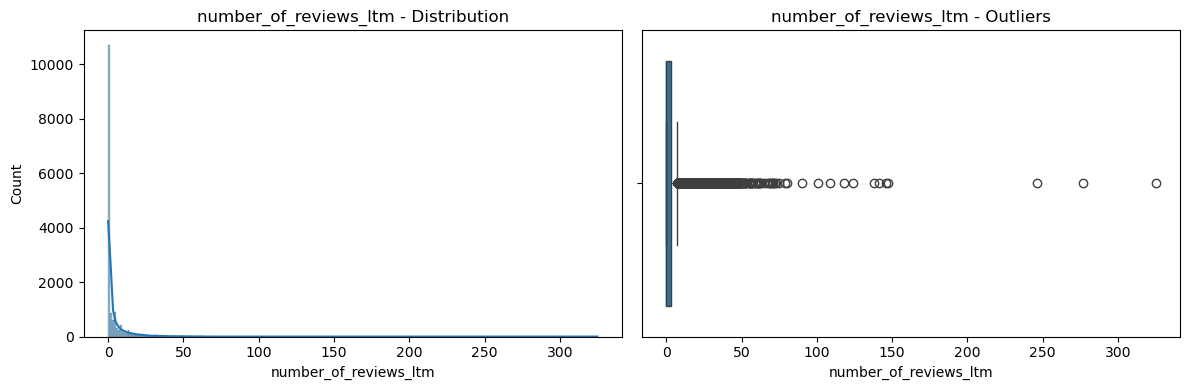

In [12]:
# Select numeric columns (exclude IDs)
cols_to_plot = [
    'price',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
    'number_of_reviews_ltm'
]

# Check distribution
for col in cols_to_plot:
    display(Markdown(f"<h3 style='text-align:center;'>Column: {col}</h3>"))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram (distribution)
    sns.histplot(df[col], ax=axes[0], kde=True)
    axes[0].set_title(f'{col} - Distribution')

    # Boxplot (outliers)
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'{col} - Outliers')

    plt.tight_layout()
    plt.show()

**Summary**:

- **Price & Minimum Nights:** Highly skewed. Most listings are low-priced, but extreme outliers reach up to **1e6** THB. Minimum nights are usually **1–7 days**, with some extreme cases over **1,000 days**, likely long-term rentals or data issues.
- **Review Activity:** Most listings have **0–50 reviews**, while a small number have hundreds. Reviews per month are mostly **near zero**, showing many listings have little or no activity.
- **Host & Availability:** Most hosts manage **1–5 listings**, but a few manage **200+**. Availability is clearly split into two groups: **0 days** (inactive/unavailable) and **365 days** (fully available).

**Takeaway**: The dataset is heavily skewed with many outliers, so price and minimum nights should be capped, skewed features should be log-transformed, and availability must be handled carefully due to its bimodal pattern (inactive vs fully available listings).

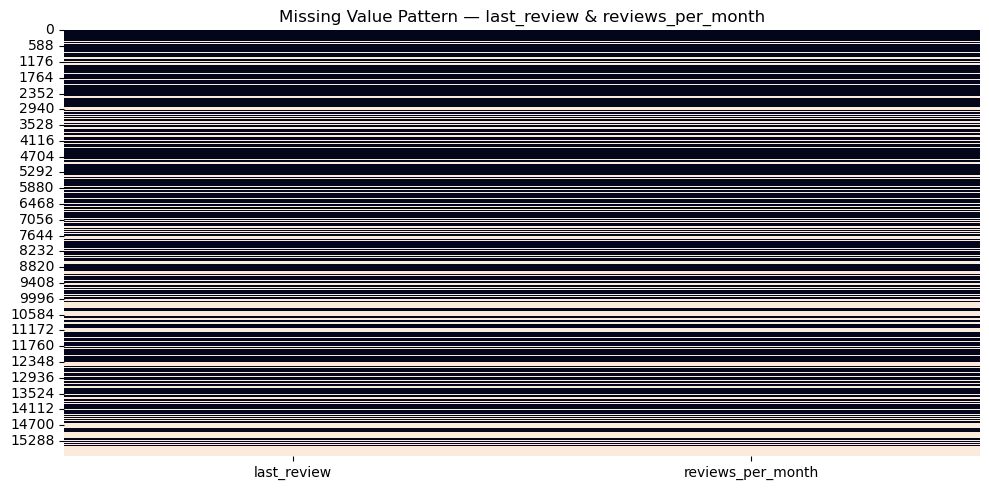

In [13]:
# Visualize missing values
plt.figure(figsize=(10, 5))

sns.heatmap(df[['last_review', 'reviews_per_month']].isna(), cbar=False)

plt.title('Missing Value Pattern — last_review & reviews_per_month')
plt.tight_layout()
plt.show()

**Why are these values missing?**

`last_review` and `reviews_per_month` are missing because those listings have no review activity recorded.

- No review exists → `last_review` remains `NaT` since there is no date to store  
- No activity detected → `reviews_per_month` is set to `0` because there are no reviews to calculate frequency from  

This is not a data issue. It simply reflects listings with no guest feedback history, which usually means they are new, inactive, or never received bookings.

In [14]:
# Transform last_review to datetime
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

We transform the `last_review` data type to enable time-based analysis and ensure a correct date format.

In [15]:
# Fill reviews_per_month with 0 → no reviews means 0 monthly activity
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# Keep last_review as NaT → indicates no review activity
df['last_review'] = df['last_review']

In [16]:
# Verify handled missing values
df[['last_review', 'reviews_per_month']].isnull().sum()

last_review          5790
reviews_per_month       0
dtype: int64

Note:
`last_review` still has missing values because listings with no reviews have no review date. This is expected.

In [17]:
# Add a flag column: 1 = has reviews, 0 = no reviews
df['has_reviews'] = (df['number_of_reviews'] > 0).astype(int)

# Preview
df[['number_of_reviews', 'last_review', 'reviews_per_month', 'has_reviews']].head()

,number_of_reviews,last_review,reviews_per_month,has_reviews
0,65,2020-01-06,0.50,1
1,0,NaT,0.00,0
2,0,NaT,0.00,0
3,2,2022-04-01,0.03,1
4,0,NaT,0.00,0


Note:
`has_reviews` helps distinguish listings with and without review activity.

#### Step 4 — Remove anomalies

We identified three columns with suspicious values during data understanding.

**Price**

In [18]:
# How many listings have price = 0?
print('Listings with price = 0 :', df[df['price'] == 0].shape[0])

Listings with price = 0 : 1


Note:
There is 1 listing with price = 0, which is likely a data error or special case and should be removed.

In [19]:
# What does the high end look like?
df[df['price'] > 10000][['neighbourhood', 'room_type', 'price']].sort_values('price', ascending=False).head(10)

,neighbourhood,room_type,price
12868,Vadhana,Entire home/apt,1100000
12300,Vadhana,Entire home/apt,1014758
1779,Huai Khwang,Entire home/apt,1000000
6289,Khlong Toei,Entire home/apt,1000000
9345,Khlong Toei,Entire home/apt,1000000
4620,Huai Khwang,Entire home/apt,1000000
1239,Huai Khwang,Entire home/apt,1000000
15200,Khlong San,Entire home/apt,710760
4373,Bang Phlat,Private room,600700
11885,Bang Kapi,Private room,429443


Note:
Extreme high prices indicate outliers that may affect pricing analysis.

In [20]:
# Drop zero-price listings
df = df[df['price'] > 0]

# Cap at 99th percentile to remove extreme outliers
price_cap = df['price'].quantile(0.99)
df = df[df['price'] <= price_cap]

print(f'Price cap (99th percentile) : {price_cap:,.0f} THB')
print(f'Rows remaining              : {df.shape[0]:,}')

Price cap (99th percentile) : 18,000 THB
Rows remaining              : 15,701


Note:
Outliers above 18,000 THB are removed, keeping the data more realistic for pricing analysis.

**Minimum nights**

In [21]:
# Check the extreme end of minimum_nights
df[df['minimum_nights'] > 365][['neighbourhood', 'room_type', 'minimum_nights']].sort_values('minimum_nights').head(10)

,neighbourhood,room_type,minimum_nights
324,Khlong Toei,Entire home/apt,370
11416,Dusit,Private room,400
8608,Lat Phrao,Entire home/apt,450
1833,Suanluang,Entire home/apt,500
3694,Vadhana,Entire home/apt,500
1592,Chatu Chak,Entire home/apt,700
10644,Vadhana,Private room,999
11243,Suanluang,Private room,999
10153,Sathon,Entire home/apt,1000
11524,Bang Sue,Entire home/apt,1095


In [22]:
print('Maximum minimum_nights:', df['minimum_nights'].max())

Maximum minimum_nights: 1125


Note:
Some listings have extremely high minimum nights (up to 1125), indicating long-term rental strategies or outliers that may affect demand analysis. These are outside the scope of this analysis → **dropped**.

In [23]:
# Keep only short-term rental listings (minimum_nights <= 365)
df = df[df['minimum_nights'] <= 365]

print(f'Rows remaining : {df.shape[0]:,}')

Rows remaining : 15,689


**Availability**

In [24]:
# How many listings have 0 days available per year?
print('Listings with availability = 0 :', df[df['availability_365'] == 0].shape[0])

Listings with availability = 0 : 850


In [25]:
df[df['availability_365'] == 0][['neighbourhood', 'room_type', 'price']].head()

,neighbourhood,room_type,price
51,Bang Rak,Entire home/apt,2701
104,Chatu Chak,Entire home/apt,1004
141,Phaya Thai,Private room,399
152,Khlong Toei,Entire home/apt,1489
205,Chatu Chak,Entire home/apt,866


Note:
850 listings have zero availability (fully booked or inactive) and don’t reflect current demand → **drop**.

In [26]:
# Keep only bookable listings
df = df[df['availability_365'] > 0]

print(f'Rows remaining : {df.shape[0]:,}')

Rows remaining : 14,839


#### Cleaning summary

Quick check on the dataset after all cleaning steps.

In [27]:
print(f'Final dataset : {df.shape[0]:,} rows  x  {df.shape[1]} columns')
print()

Final dataset : 14,839 rows  x  15 columns



In [28]:
df[['price', 'minimum_nights', 'availability_365']].describe().round(0)

,price,minimum_nights,availability_365
count,14839.0,14839.0,14839.0
mean,2059.0,15.0,258.0
std,2112.0,45.0,115.0
min,278.0,1.0,1.0
25%,900.0,1.0,161.0
50%,1422.0,1.0,321.0
75%,2366.0,7.0,361.0
max,18000.0,365.0,365.0


**Summary**
- Price: Heavily right-skewed. Mean is 2,059 and median is 1,422, with high variance (std 2,112) and values up to 18,000.
- Minimum Nights: Mostly short-term stays. Median is 1 night, with extreme outliers up to 365 nights.
- Availability (365 Days): Generally high. Median is 321 days, meaning most listings are available most of the year.

## Exploratory Data Analysis

We now explore the data to answer our two business questions:

- **Q1.** What pricing strategies maximize demand by neighbourhood and room type?
- **Q2.** Which combination of price, neighbourhood, and room type performs best?

We start with individual variables, then look at relationships between them.

#### Price distribution

Understanding the overall price landscape before breaking it down by location and room type.

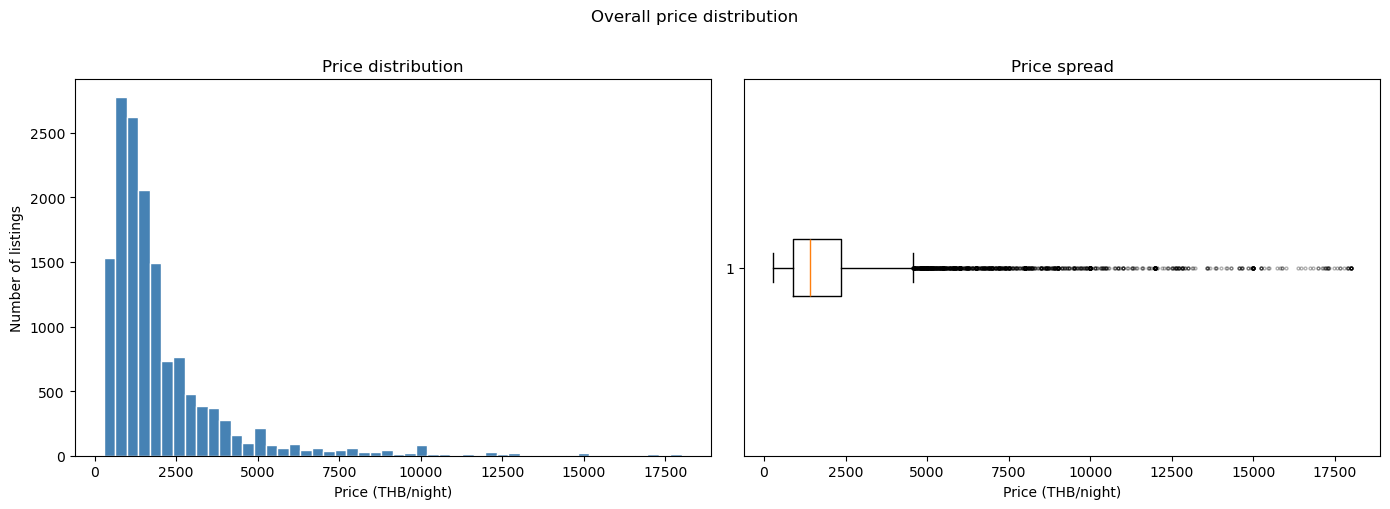

In [29]:
# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(df['price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Price distribution')
axes[0].set_xlabel('Price (THB/night)')
axes[0].set_ylabel('Number of listings')

# Spread
axes[1].boxplot(df['price'], vert=False,
                flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[1].set_title('Price spread')
axes[1].set_xlabel('Price (THB/night)')

plt.suptitle('Overall price distribution', y=1.01)
plt.tight_layout()
plt.show()

In [30]:
# Key stats
price_stats = df['price'].describe().round(0).to_frame()
price_stats

,price
count,14839.0
mean,2059.0
std,2112.0
min,278.0
25%,900.0
50%,1422.0
75%,2366.0
max,18000.0


**Findings (Price)**:
- Prices are right-skewed; the mean is 2,059 THB, which is higher than the median (1,422 THB).
- Most listings fall between 900–2,366 THB (25%–75% range)
- Minimum is 278 THB, while maximum reaches 18,000 THB
- Overall, a small number of high-end listings pull the average up

#### Price by room type

How does price differ between room categories?

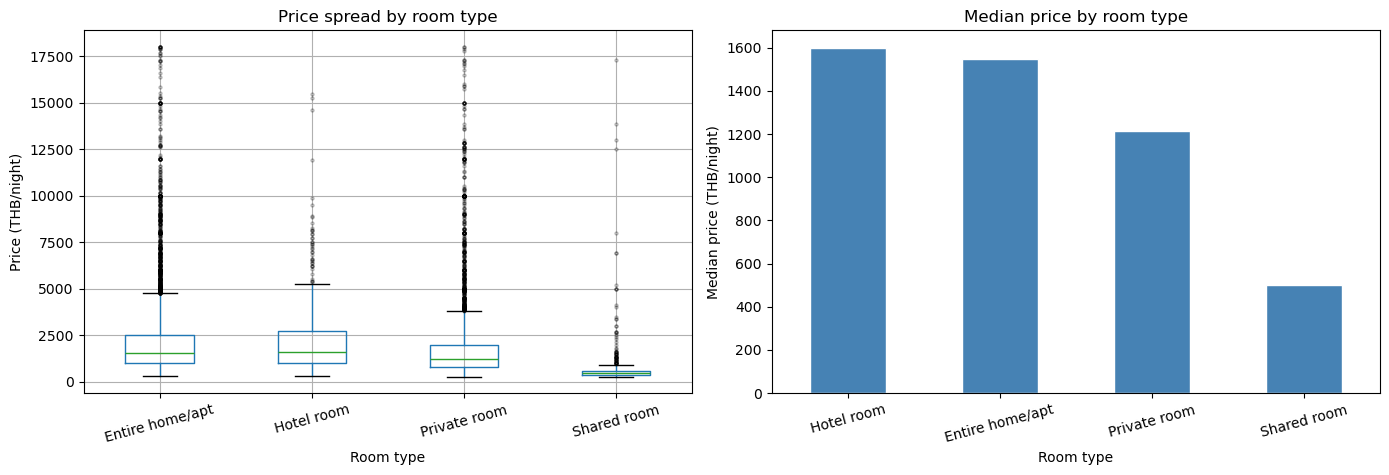

In [31]:
# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spread per room type
df.boxplot(column='price', by='room_type', ax=axes[0],
           flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[0].set_title('Price spread by room type')
axes[0].set_xlabel('Room type')
axes[0].set_ylabel('Price (THB/night)')
plt.sca(axes[0])
plt.xticks(rotation=15)
plt.suptitle('')  # remove default suptitle from boxplot

# Median price
df.groupby('room_type')['price'].median()   .sort_values(ascending=False)   .plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Median price by room type')
axes[1].set_xlabel('Room type')
axes[1].set_ylabel('Median price (THB/night)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [58]:
# Supply distribution (%)
supply_dist = df['room_type'].value_counts(normalize=True) * 100

# Median price per room type
median_price = df.groupby('room_type')['price'].median()

# Combine into one clean table
summary = (
    pd.DataFrame({
        'Supply (%)': supply_dist,
        'Median Price (THB)': median_price
    })
    .sort_values(by='Supply (%)', ascending=False)
)

print(summary.round(2))

                 Supply (%)  Median Price (THB)
room_type                                      
Entire home/apt       56.05              1543.5
Private room          36.74              1212.0
Hotel room             3.80              1600.0
Shared room            3.41               500.0


In [32]:
# Stats table
room_type_stats = df.groupby('room_type')['price'].describe().round(0).reset_index()
room_type_stats

,room_type,count,mean,std,min,25%,50%,75%,max
0,Entire home/apt,8318.0,2212.0,2096.0,332.0,1030.0,1546.0,2527.0,18000.0
1,Hotel room,563.0,2249.0,2041.0,318.0,1000.0,1600.0,2716.0,15442.0
2,Private room,5453.0,1922.0,2149.0,278.0,800.0,1212.0,2000.0,18000.0
3,Shared room,505.0,820.0,1457.0,280.0,390.0,500.0,600.0,17316.0


**Findings:**
- Entire home/apt: highest variability and upper prices (median ~1,546 THB, max 18,000).
- Hotel room: high pricing, median ~1,600 THB, limited listings.
- Private room: mid-range, median ~1,212 THB.
- Shared room: cheapest option, median ~500 THB.
- Entire home/apt has the widest price spread, showing the most flexible pricing.

#### Price by neighbourhood

Which areas command premium prices, and which are budget-friendly?

In [33]:
# Remove irrelevant neighbourhood
df = df[df['neighbourhood'] != 'Nong Chok']

Note:
Nong Chok should be removed as it is located on the far edge of Bangkok. Its low representation but high median values can distort neighbourhood and pricing analysis, affecting the overall results.

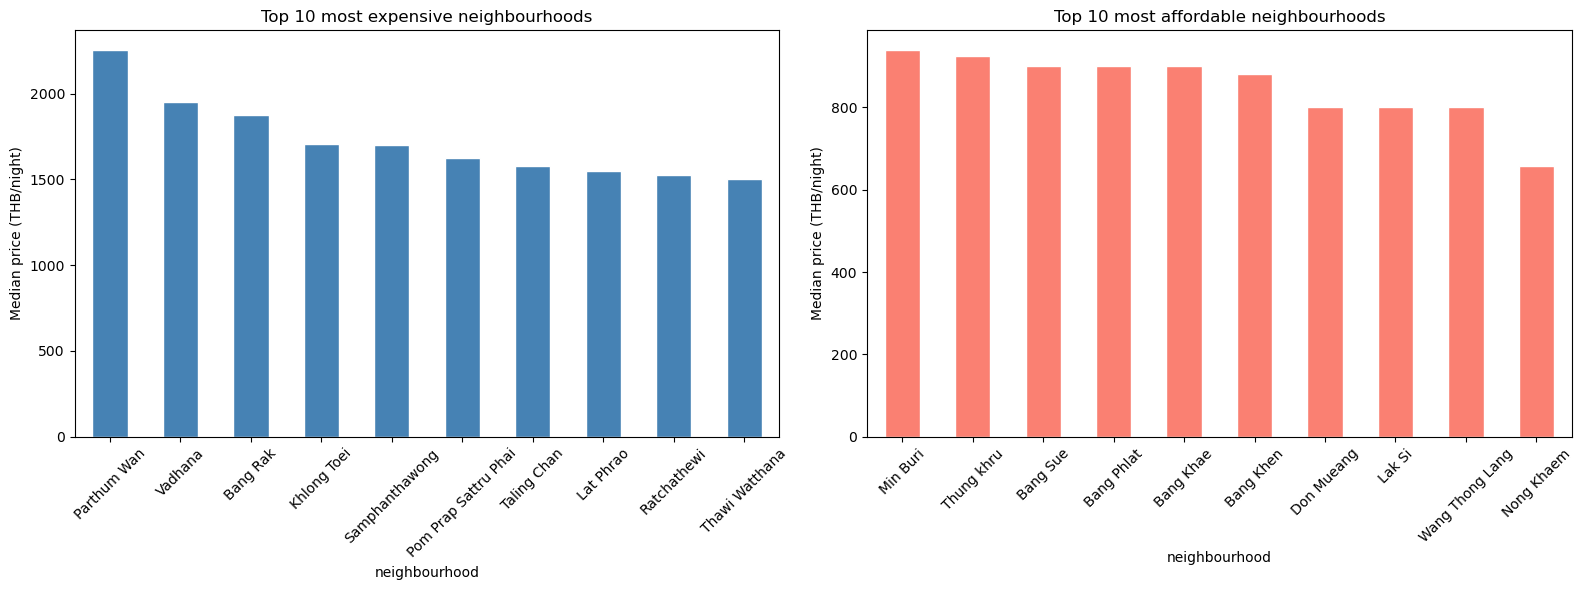

In [34]:
# Median price per neighbourhood, sorted highest to lowest
neighbourhood_price = df.groupby('neighbourhood')['price'].median().sort_values(ascending=False)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 most expensive
neighbourhood_price.head(10).plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 10 most expensive neighbourhoods')
axes[0].set_ylabel('Median price (THB/night)')
axes[0].tick_params(axis='x', rotation=45)

# Top 10 most affordable
neighbourhood_price.tail(10).plot(kind='bar', ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Top 10 most affordable neighbourhoods')
axes[1].set_ylabel('Median price (THB/night)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [35]:
# Neighbourhood price table
df_neighbourhood = neighbourhood_price.reset_index().rename(
    columns={'price': 'median_price (THB)'}
)

display(df_neighbourhood.head(), df_neighbourhood.tail())

,neighbourhood,median_price (THB)
0,Parthum Wan,2257.0
1,Vadhana,1950.0
2,Bang Rak,1874.0
3,Khlong Toei,1707.0
4,Samphanthawong,1700.0


,neighbourhood,median_price (THB)
44,Bang Khen,880.0
45,Don Mueang,800.0
46,Lak Si,800.0
47,Wang Thong Lang,800.0
48,Nong Khaem,658.0


**Findings**:
- Highest-priced neighbourhoods (Pathum Wan, Vadhana, Bang Rak) are centrally located near major transport lines and business districts.
- Lowest-priced areas (Nong Khaem, Don Mueang, Lak Si) are on the outskirts of Bangkok.
- Median prices range from 658 THB to 2,257 THB, showing a significant location-driven gap (~3–4x).
- Location is a key driver of Airbnb pricing.

#### Demand analysis

Since actual booking data is not available, we use `number_of_reviews`, `reviews_per_month`, and `last_review` as demand proxies. Listings with more reviews and recent review activity are assumed to have higher booking demand.

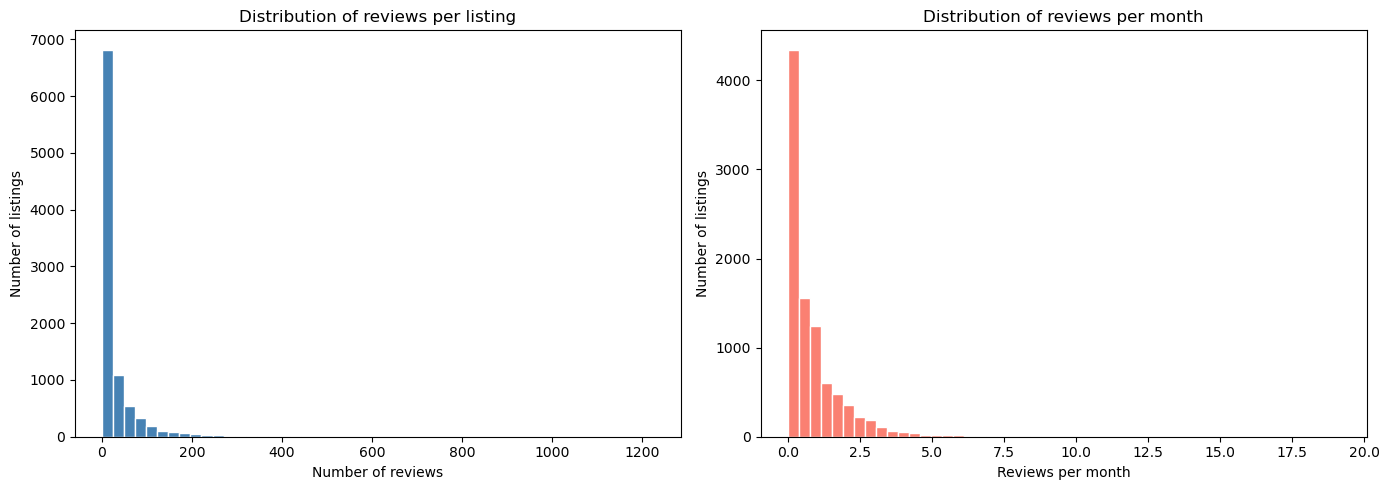

In [36]:
# Review volume & intensity distribution
# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Review count distribution (listings with at least 1 review)
axes[0].hist(df[df['number_of_reviews'] > 0]['number_of_reviews'],
             bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of reviews per listing')
axes[0].set_xlabel('Number of reviews')
axes[0].set_ylabel('Number of listings')

# Reviews per month distribution
axes[1].hist(df[df['reviews_per_month'] > 0]['reviews_per_month'],
             bins=50, color='salmon', edgecolor='white')
axes[1].set_title('Distribution of reviews per month')
axes[1].set_xlabel('Reviews per month')
axes[1].set_ylabel('Number of listings')

plt.tight_layout()
plt.show()

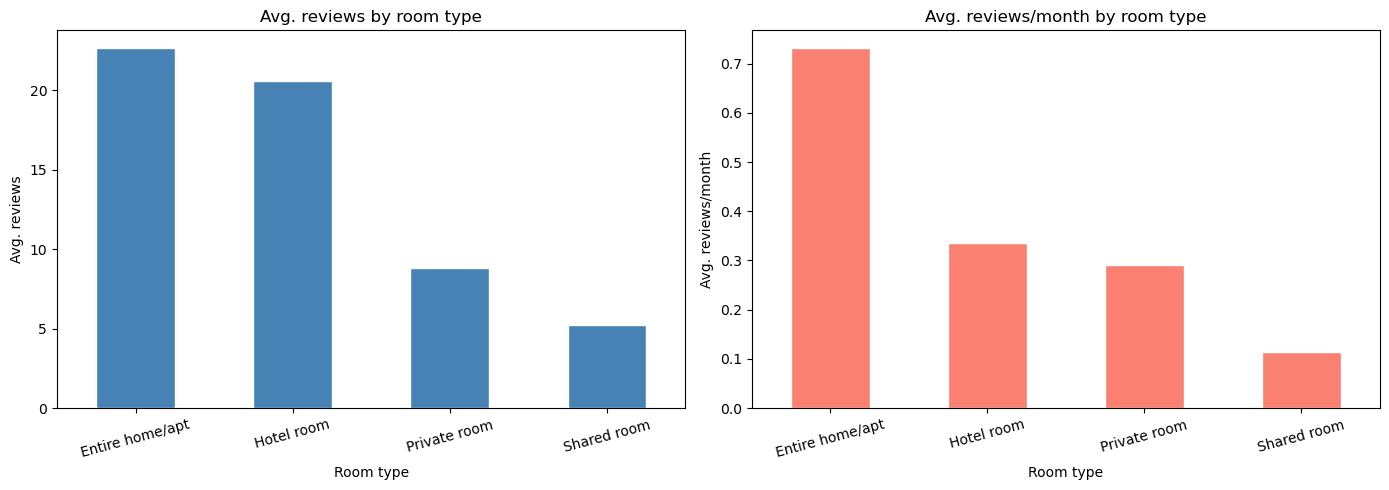

In [37]:
# Demand by room type
# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Median reviews by room type
df.groupby('room_type')['number_of_reviews'].mean() \
    .sort_values(ascending=False) \
    .plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Avg. reviews by room type')
axes[0].set_xlabel('Room type')
axes[0].set_ylabel('Avg. reviews')
axes[0].tick_params(axis='x', rotation=15)

# Median reviews/month by room type
df.groupby('room_type')['reviews_per_month'].mean() \
    .sort_values(ascending=False) \
    .plot(kind='bar', ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Avg. reviews/month by room type')
axes[1].set_xlabel('Room type')
axes[1].set_ylabel('Avg. reviews/month')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

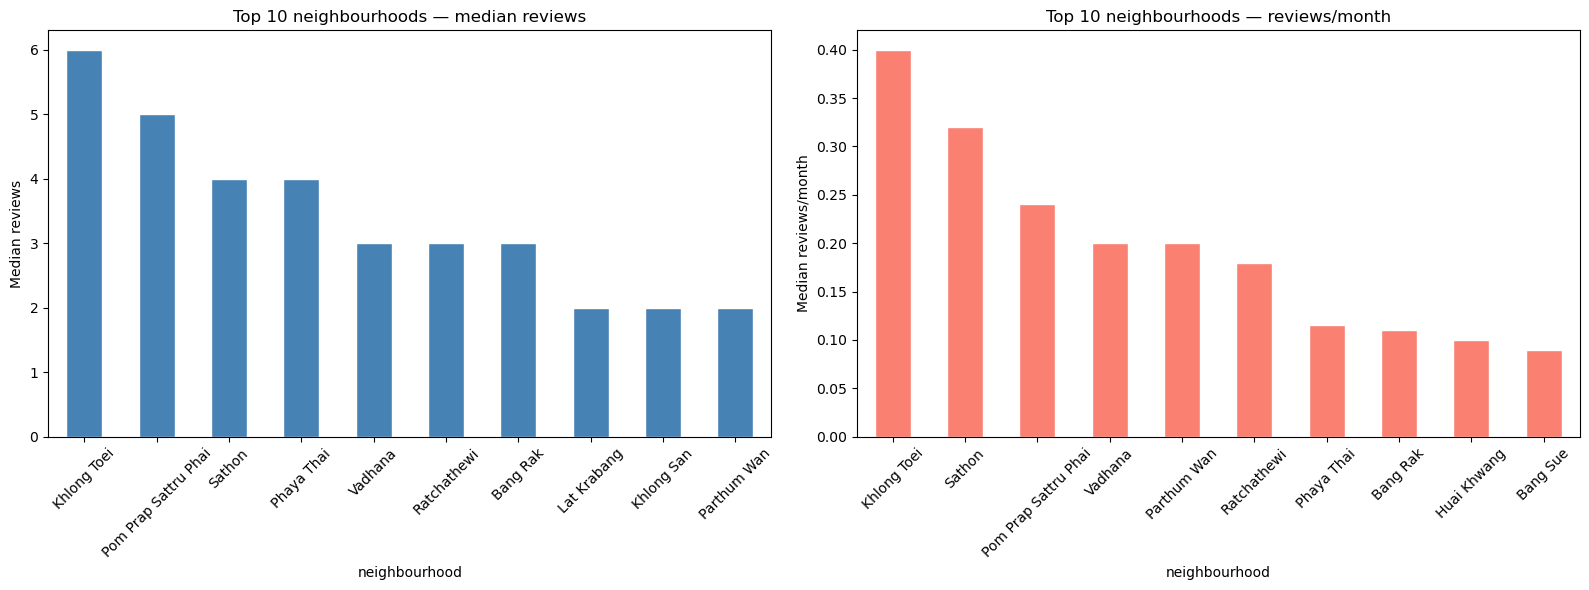

In [38]:
# Demand by neighbourhood
# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top neighbourhoods by median reviews
df.groupby('neighbourhood')['number_of_reviews'].median() \
    .sort_values(ascending=False).head(10) \
    .plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 10 neighbourhoods — median reviews')
axes[0].set_ylabel('Median reviews')
axes[0].tick_params(axis='x', rotation=45)

# Top neighbourhoods by reviews/month
df.groupby('neighbourhood')['reviews_per_month'].median() \
    .sort_values(ascending=False).head(10) \
    .plot(kind='bar', ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Top 10 neighbourhoods — reviews/month')
axes[1].set_ylabel('Median reviews/month')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

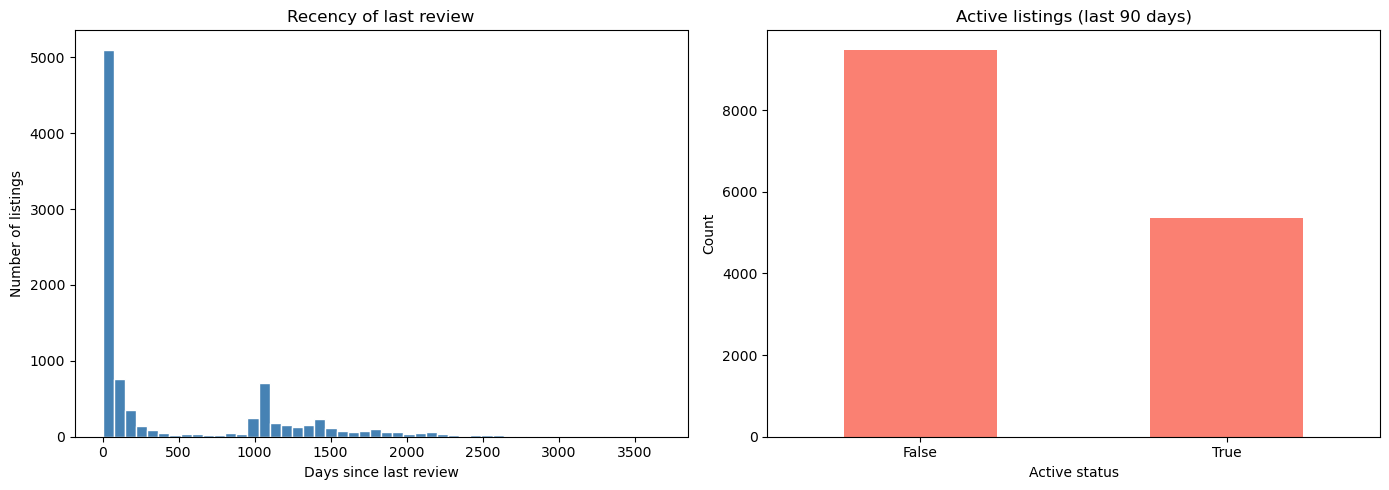

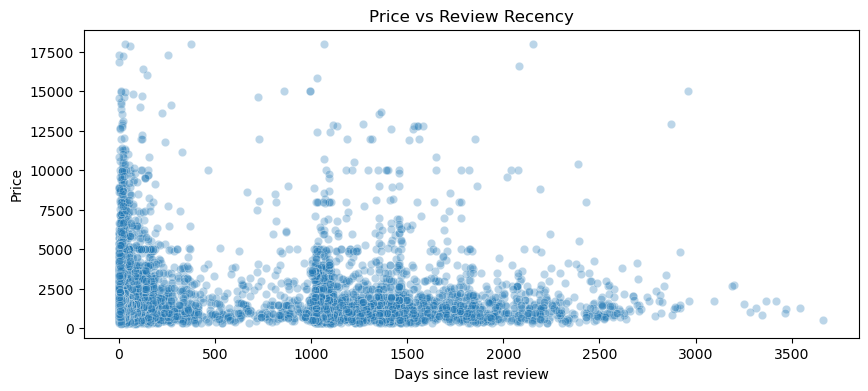

In [39]:
# Last review (recency / activity signal)
# Convert to datetime + create recency feature
df['last_review'] = pd.to_datetime(df['last_review'])
df['days_since_last_review'] = (df['last_review'].max() - df['last_review']).dt.days

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recency distribution
axes[0].hist(df['days_since_last_review'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Recency of last review')
axes[0].set_xlabel('Days since last review')
axes[0].set_ylabel('Number of listings')

# Active vs inactive (90 days)
df['active_90d'] = df['days_since_last_review'] <= 90
df['active_90d'].value_counts().plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Active listings (last 90 days)')
axes[1].set_xlabel('Active status')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Price vs recency
plt.figure(figsize=(10,4))

sns.scatterplot(
    data=df,
    x='days_since_last_review',
    y='price',
    alpha=0.3
)

plt.title('Price vs Review Recency')
plt.xlabel('Days since last review')
plt.ylabel('Price')
plt.show()

**Findings**:
- ~36.5% of listings have no reviews, showing a large inactive demand segment.
- Demand is highly skewed, a small group of listings drives most activity.
- ~10,000 listings are inactive (no recent reviews), while ~5,000–6,000 show active demand.
- Entire homes/apartments lead demand across both total and monthly reviews.
- Demand clusters in Khlong Toei, Sathon, and nearby central areas.
- Lower-to-mid prices (<2,500–5,000) attract most demand; luxury listings have weaker demand.

**Conclusion**:
High-demand listings are entire homes in central areas, priced in the mid-range, with consistent review activity.

#### Price vs demand

This is the core relationship for answering **Q1**: which segments drive the most demand?

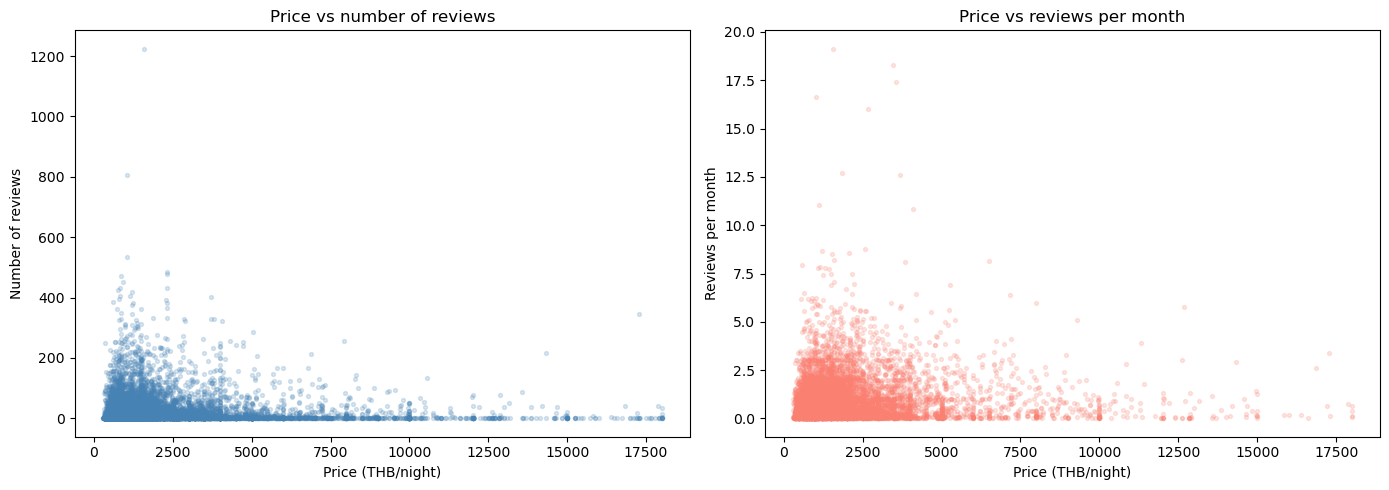

In [40]:
# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: price vs reviews
axes[0].scatter(df['price'], df['number_of_reviews'],
                alpha=0.2, color='steelblue', s=8)
axes[0].set_title('Price vs number of reviews')
axes[0].set_xlabel('Price (THB/night)')
axes[0].set_ylabel('Number of reviews')

# Scatter: price vs reviews/month (reviewed listings only)
reviewed = df[df['reviews_per_month'] > 0]
axes[1].scatter(reviewed['price'], reviewed['reviews_per_month'],
                alpha=0.2, color='salmon', s=8)
axes[1].set_title('Price vs reviews per month')
axes[1].set_xlabel('Price (THB/night)')
axes[1].set_ylabel('Reviews per month')

plt.tight_layout()
plt.show()

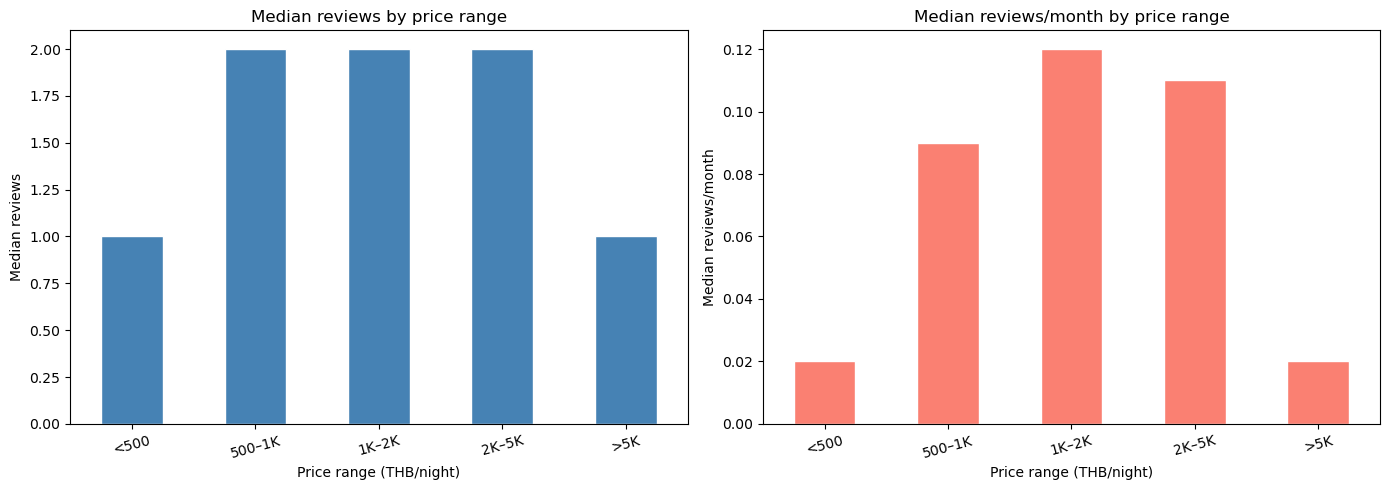

In [41]:
# Group price into buckets to compare demand clearly
df['price_bucket'] = pd.cut(
    df['price'],
    bins=[0, 500, 1000, 2000, 5000, df['price'].max()],
    labels=['<500', '500–1K', '1K–2K', '2K–5K', '>5K']
)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('price_bucket', observed=True)['number_of_reviews'].median()   .plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Median reviews by price range')
axes[0].set_xlabel('Price range (THB/night)')
axes[0].set_ylabel('Median reviews')
axes[0].tick_params(axis='x', rotation=15)

df.groupby('price_bucket', observed=True)['reviews_per_month'].median()   .plot(kind='bar', ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Median reviews/month by price range')
axes[1].set_xlabel('Price range (THB/night)')
axes[1].set_ylabel('Median reviews/month')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

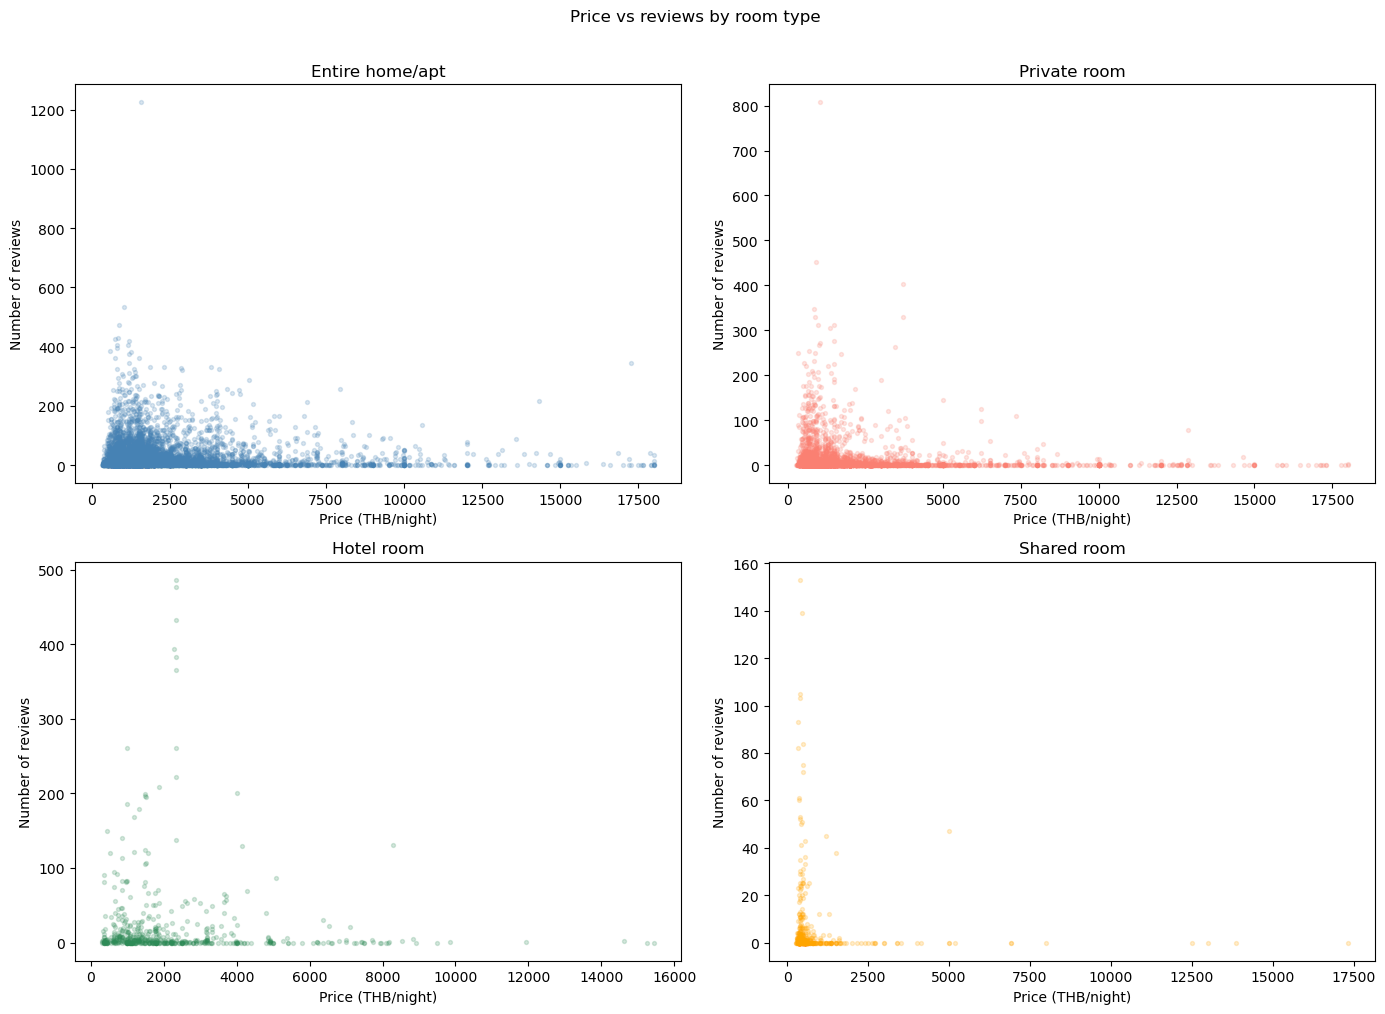

In [42]:
# Price vs demand broken down by room type
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
room_types = df['room_type'].unique()
colors = ['steelblue', 'salmon', 'seagreen', 'orange']

for ax, room, color in zip(axes.flatten(), room_types, colors):
    subset = df[df['room_type'] == room]
    ax.scatter(subset['price'], subset['number_of_reviews'],
               alpha=0.2, color=color, s=8)
    ax.set_title(f'{room}')
    ax.set_xlabel('Price (THB/night)')
    ax.set_ylabel('Number of reviews')

plt.suptitle('Price vs reviews by room type', y=1.01)
plt.tight_layout()
plt.show()

**Findings**:
- Clear inverse relationship, **lower prices segment generally attract higher review activity** (higher demand).
- Strongest demand is concentrated in the 1,000–2,000 THB/night range.
- Demand drops significantly above 5,000 THB/night, regardless of room type.
- Private rooms show the highest sensitivity, with strongest demand in the 800–1,500 THB range.
- Ultra-low prices (<500 THB) do not guarantee high demand, suggesting quality/location effects.
 
**Conclusion**:
Pricing strongly impacts demand, with the optimal range around 1,000–2,000 THB/night for maximum booking activity, while prices above 5,000 THB shift listings into low-frequency luxury demand.

#### Correlation heatmap

A quick overview of how all numeric variables relate to each other.

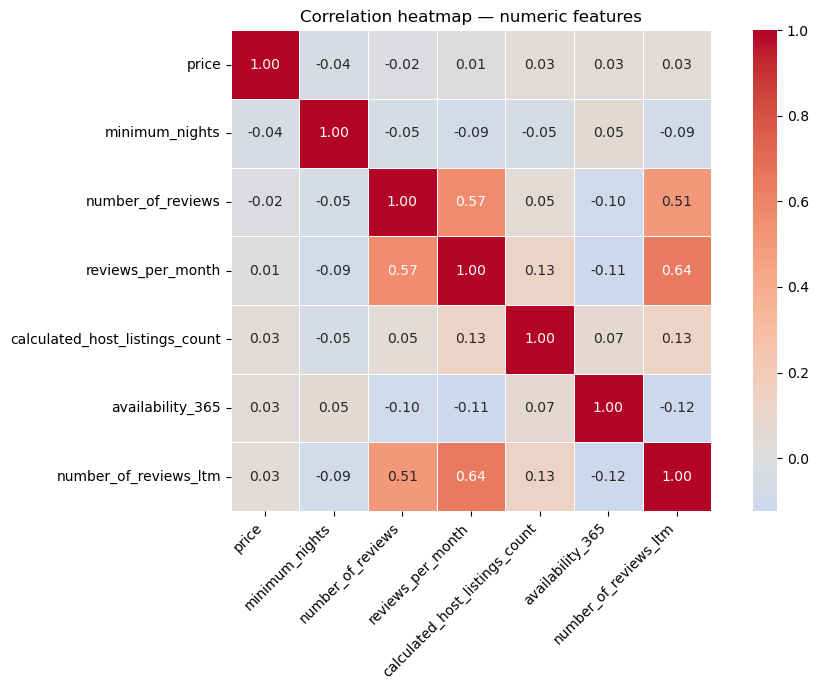

In [43]:
corr_cols = [
    'price', 'minimum_nights', 'number_of_reviews',
    'reviews_per_month', 'calculated_host_listings_count',
    'availability_365', 'number_of_reviews_ltm'
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, square=True
)
plt.title('Correlation heatmap — numeric features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Findings**:

- Strong multicollinearity between `number_of_reviews`, `reviews_per_month`, and `number_of_reviews_ltm` (r ≈ 0.51–0.64), all measuring the same booking activity signal.  
- `price` has a very weak negative correlation with demand (≈ -0.02 to -0.04), indicating limited linear effect on bookings.  
- `availability_365` shows a weak negative relationship with demand (≈ -0.11), meaning higher availability does not guarantee more bookings.  
- `minimum_nights` has a weak negative correlation (≈ -0.05 to -0.09), suggesting longer stays slightly reduce booking frequency.  
- `calculated_host_listings_count` has a weak positive correlation (≈ 0.13), indicating multi-listing hosts may perform slightly better.  


**Summary**:
Demand features are strongly interrelated, while price, availability, and minimum stay show only weak linear relationships with booking activity.

#### Price spread by neighbourhood

Median price tells us where the centre is, but the spread tells us how consistent or risky pricing is within each area.

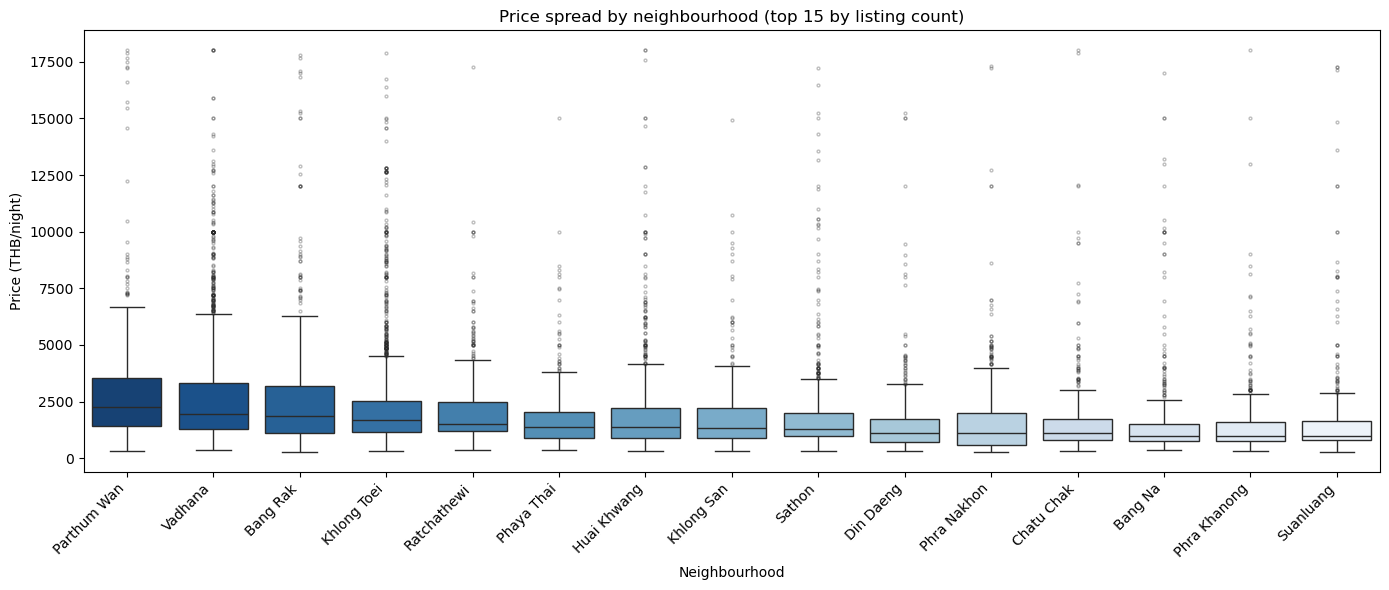

In [44]:
# Focus on the 15 most-listed neighbourhoods for readability
top_15 = df['neighbourhood'].value_counts().head(15).index
df_top15 = df[df['neighbourhood'].isin(top_15)]
order = df_top15.groupby('neighbourhood')['price'].median().sort_values(ascending=False).index

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_top15,
    x='neighbourhood', y='price',
    order=order,
    palette='Blues_r',
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
plt.title('Price spread by neighbourhood (top 15 by listing count)')
plt.xlabel('Neighbourhood')
plt.ylabel('Price (THB/night)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [45]:
# Summary stats
neighbourhood_stats = (
    df_top15.groupby('neighbourhood')['price']
    .agg(['median', 'std', 'min', 'max'])
    .sort_values('median', ascending=False)
    .round(0)
    .reset_index()
)

neighbourhood_stats

,neighbourhood,median,std,min,max
0,Parthum Wan,2257.0,2816.0,331,18000
1,Vadhana,1950.0,2435.0,350,18000
2,Bang Rak,1874.0,2405.0,295,17791
3,Khlong Toei,1707.0,2146.0,332,17886
4,Ratchathewi,1529.0,1353.0,346,17281
5,Phaya Thai,1385.0,1529.0,360,15000
6,Huai Khwang,1375.0,2066.0,313,18000
7,Khlong San,1350.0,1792.0,330,14943
8,Sathon,1300.0,1994.0,318,17216
9,Din Daeng,1129.0,1793.0,329,15243


**Findings**:

- Premium neighbourhoods like **Parthum Wan (std ~2816 THB)**, **Vadhana (std ~2435 THB)**, and **Bang Rak (std ~2405 THB)** show the widest price dispersion, indicating strong competition and a mix of budget to luxury listings.  
- High-variability areas such as **Khlong Toei (std ~2146 THB)** and **Huai Khwang (std ~2066 THB)** also reflect diverse market segments within the same neighbourhood.  
- More stable pricing appears in areas like **Phra Khanong (std ~1543 THB)** and **Phaya Thai (std ~1529 THB)**, making them more predictable for new hosts.  
- Nearly all neighbourhoods have extreme max prices (15,000–18,000 THB), showing consistent presence of luxury outliers that skew the distribution.

#### Review rate by neighbourhood

Not all areas are equally active. This shows the share of listings per neighbourhood with at least one review as a proxy for market activity.

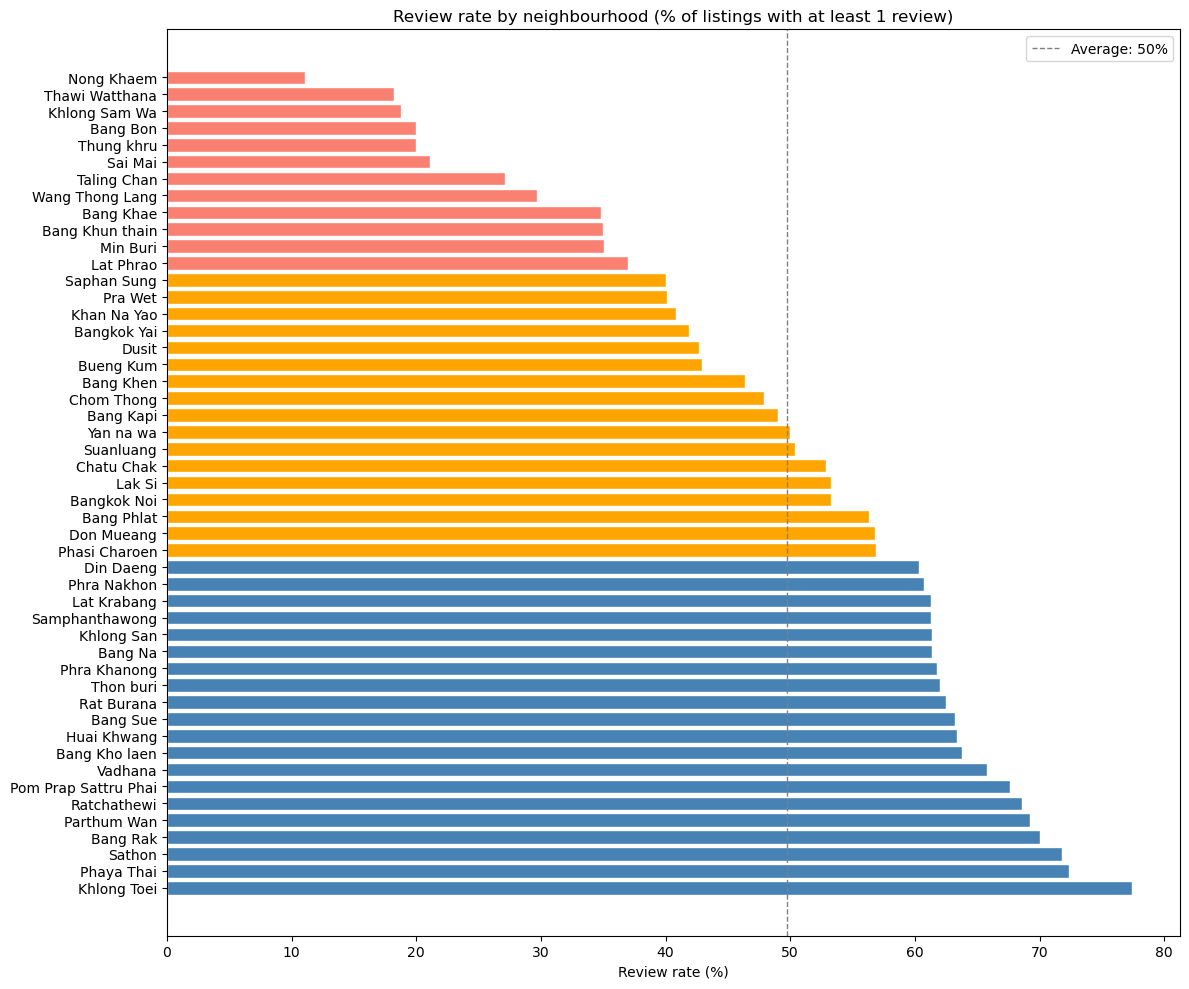

In [46]:
# Calculate review rate per neighbourhood
review_rate = df.groupby('neighbourhood').agg(
    total_listings=('has_reviews', 'count'),
    reviewed_listings=('has_reviews', 'sum')
).reset_index()

review_rate['review_rate_%'] = (
    review_rate['reviewed_listings'] / review_rate['total_listings'] * 100
).round(1)

review_rate = review_rate.sort_values('review_rate_%', ascending=False)
avg_rate = review_rate['review_rate_%'].mean()

# Color code: blue = high activity, yellow = moderate, red = low
bar_colors = ['steelblue' if r >= 60 else 'orange' if r >= 40 else 'salmon'
              for r in review_rate['review_rate_%']]

plt.figure(figsize=(12, 10))
plt.barh(review_rate['neighbourhood'], review_rate['review_rate_%'],
         color=bar_colors, edgecolor='white')
plt.axvline(avg_rate, color='gray', linestyle='--', linewidth=1,
            label=f'Average: {avg_rate:.0f}%')
plt.title('Review rate by neighbourhood (% of listings with at least 1 review)')
plt.xlabel('Review rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
# Top 10
print('Top 10 (most active)')
display(review_rate.head(10)[['neighbourhood', 'total_listings', 'review_rate_%']])

Top 10 (most active)


,neighbourhood,total_listings,review_rate_%
22,Khlong Toei,1997,77.4
30,Phaya Thai,402,72.4
40,Sathon,777,71.8
8,Bang Rak,760,70.0
28,Parthum Wan,419,69.2
36,Ratchathewi,1057,68.6
33,Pom Prap Sattru Phai,111,67.6
46,Vadhana,2007,65.8
4,Bang Kho laen,138,63.8
18,Huai Khwang,962,63.4


In [48]:
# Bottom 10
print('Bottom 10 (least active)')
display(review_rate.tail(10)[['neighbourhood', 'total_listings', 'review_rate_%']])

Bottom 10 (least active)


,neighbourhood,total_listings,review_rate_%
5,Bang Khun thain,20,35.0
2,Bang Khae,89,34.8
47,Wang Thong Lang,91,29.7
42,Taling Chan,48,27.1
37,Sai Mai,38,21.1
45,Thung khru,20,20.0
0,Bang Bon,5,20.0
20,Khlong Sam Wa,32,18.8
43,Thawi Watthana,11,18.2
27,Nong Khaem,9,11.1


**Findings**

- Review rate varies significantly, from ~77% in top areas (e.g., Khlong Toei) down to ~11% in the least active (e.g., Nong Khaem).  
- High-activity areas include Khlong Toei (77.4%), Phaya Thai (72.4%), and Sathon (71.8%), indicating strong and consistent demand.  
- Low-activity areas such as Nong Khaem (11.1%), Thawi Watthana (18.2%), and Khlong Sam Wa (18.8%) show weak market engagement.  
- Neighbourhoods with high review rates align with earlier demand hotspots, confirming consistent demand signals across metrics.

#### Best combination: neighbourhood + room type + price

Answering **Q2**: Which neighbourhood,room and price combo is most consistent?

In [49]:
# Aggregate metrics per neighbourhood + room type combination
combo = df.groupby(['neighbourhood', 'room_type']).agg(
    listing_count   = ('price', 'count'),
    median_price    = ('price', 'median'),
    median_reviews  = ('number_of_reviews', 'median'),
    median_rpm      = ('reviews_per_month', 'median'),
).reset_index()

# Only include combinations with at least 10 listings (statistically meaningful)
combo = combo[combo['listing_count'] >= 10]

# Normalize demand metrics to 0–1 scale
for col in ['median_reviews', 'median_rpm']:
    combo[f'{col}_norm'] = (combo[col] - combo[col].min()) / (combo[col].max() - combo[col].min())

# Performance score = average of both normalized demand metrics
combo['performance_score'] = combo[['median_reviews_norm', 'median_rpm_norm']].mean(axis=1)

# Top 10 combinations
top_combos = combo.sort_values('performance_score', ascending=False).head(50).copy()
top_combos[['neighbourhood', 'room_type', 'listing_count',
            'median_price', 'median_reviews', 'median_rpm', 'performance_score']].round(2)

,neighbourhood,room_type,listing_count,median_price,median_reviews,median_rpm,performance_score
82,Lat Krabang,Hotel room,14,1288.0,28.0,0.60,0.98
27,Bang Rak,Entire home/apt,312,2426.5,13.0,0.61,0.72
74,Khlong Toei,Entire home/apt,1467,1743.0,9.0,0.62,0.66
101,Phaya Thai,Entire home/apt,191,1500.0,15.0,0.41,0.60
136,Sathon,Entire home/apt,536,1391.0,7.0,0.58,0.59
155,Vadhana,Entire home/apt,1370,2043.0,5.0,0.43,0.44
109,Phra Nakhon,Entire home/apt,49,2262.0,9.0,0.31,0.41
93,Parthum Wan,Entire home/apt,232,2484.5,5.0,0.40,0.41
113,Pom Prap Sattru Phai,Entire home/apt,48,2045.5,6.5,0.32,0.38
123,Ratchathewi,Entire home/apt,629,1632.0,4.0,0.38,0.38


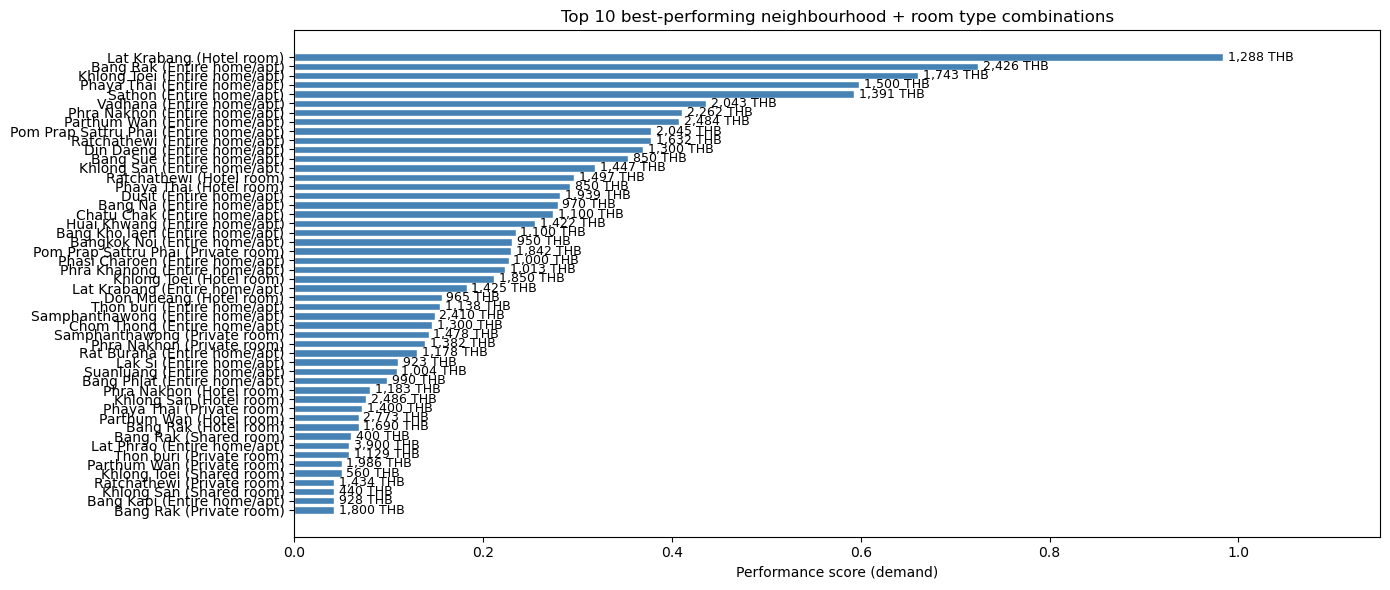

In [50]:
# Visualize top 10 combinations
fig, ax = plt.subplots(figsize=(14, 6))

top_combos['label'] = top_combos['neighbourhood'] + ' (' + top_combos['room_type'] + ')'
bars = ax.barh(top_combos['label'], top_combos['performance_score'],
               color='steelblue', edgecolor='white')

# Annotate each bar with median price
for bar, price in zip(bars, top_combos['median_price']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{int(price):,} THB', va='center', fontsize=9)

ax.set_title('Top 10 best-performing neighbourhood + room type combinations')
ax.set_xlabel('Performance score (demand)')
ax.invert_yaxis()
ax.set_xlim(0, 1.15)
plt.tight_layout()
plt.show()

In [51]:
cols = ['neighbourhood', 'room_type', 'performance_score', 'median_price']
top_combos[cols].to_csv("top_combos_clean.csv", index=False)

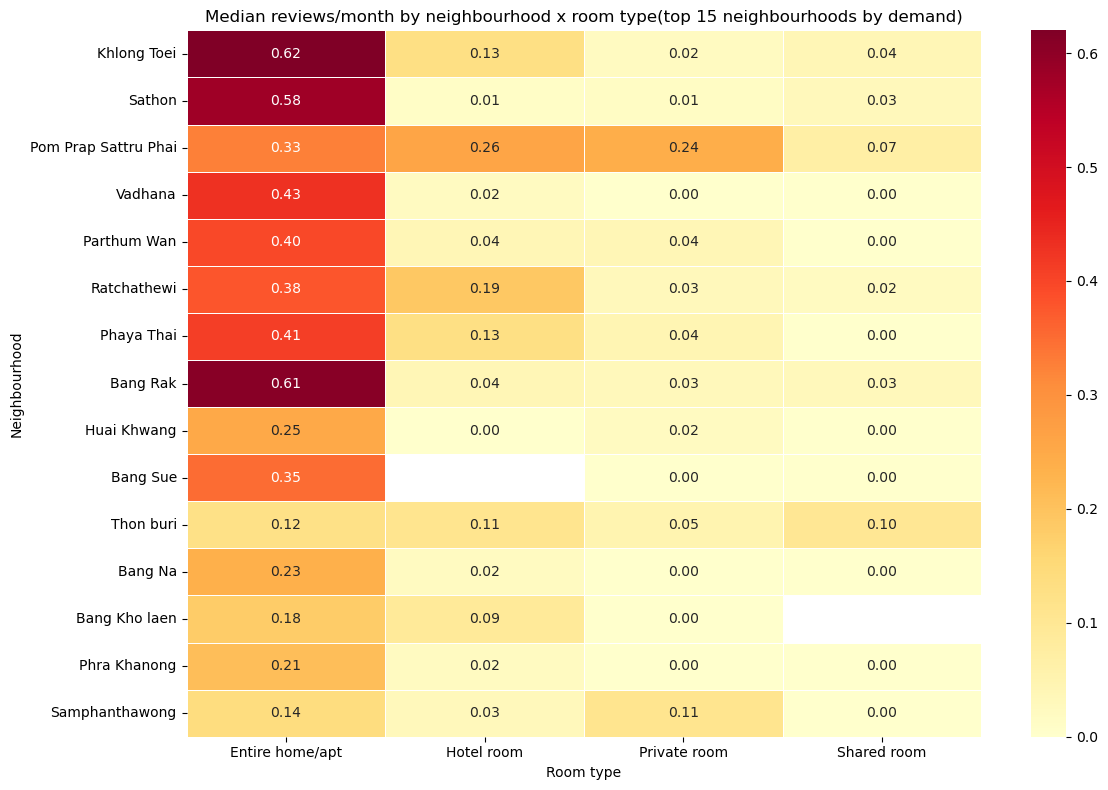

In [52]:
# Heatmap: reviews/month by neighbourhood x room type (top 15 neighbourhoods)
pivot = df.groupby(['neighbourhood', 'room_type'])['reviews_per_month'].median().unstack()

top_neighbourhoods = df.groupby('neighbourhood')['reviews_per_month'].median().sort_values(ascending=False).head(15).index
pivot = pivot.loc[top_neighbourhoods]

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('Median reviews/month by neighbourhood x room type(top 15 neighbourhoods by demand)')
plt.xlabel('Room type')
plt.ylabel('Neighbourhood')
plt.tight_layout()
plt.show()

**Findings**:

- The strongest-performing combinations are concentrated in transit-accessible, mid-tier neighbourhoods rather than purely premium areas.  
- **Entire home/apt in Bang Rak, Khlong Toei, and Phaya Thai** consistently shows high and stable performance (scores ~0.60–0.72).  
- The top individual performer is **Hotel room in Lat Krabang**, driven by very high booking velocity (score ~0.98), likely linked to airport transit demand.  
- Demand is most consistent in the **1,200–2,500 THB price range**; performance drops as listings move into higher price tiers.  
- Heatmap results show **Khlong Toei, Bang Rak, and Sathon** as “powerhouse” areas with strong demand across multiple room types, while **Pom Prap Sattru Phai** is the most balanced across all categories.  

**Conclusion**:
The most consistent high-performance setup is **Entire home/apt in Bang Rak or Khlong Toei (1,700–2,400 THB)**, while the highest velocity niche is **Hotel rooms in Lat Krabang (~1,300 THB)**.

#### Neighbourhood strategy map

An interactive map showing each Bangkok neighbourhood colored by its recommended hosting strategy, based on our analysis.

In [53]:
# Install folium (run once)
!pip install folium geopandas -q

In [54]:
# Assign strategy tier based on median price and demand analysis
high_revenue = ['Parthum Wan', 'Bang Rak', 'Sathon', 'Dusit', 'Phra Nakhon',
                'Samphanthawong', 'Bang Phlat', 'Khlong San']

high_volume  = ['Vadhana', 'Khlong Toei', 'Ratchathewi', 'Phaya Thai',
                'Huai Khwang', 'Wang Thong Lang', 'Phra Khanong', 'Yan na wa',
                'Chatu Chak', 'Lat Phrao']

def get_strategy(neighbourhood):
    if neighbourhood in high_revenue:
        return 'High Revenue'
    elif neighbourhood in high_volume:
        return 'High Volume'
    else:
        return 'Balanced'

df['strategy'] = df['neighbourhood'].apply(get_strategy)
df['strategy'].value_counts()

strategy
High Volume     7808
Balanced        3781
High Revenue    3236
Name: count, dtype: int64

In [55]:
import folium
import requests

strategy_colors = {
    'High Revenue': '#EA4335',
    'High Volume' : '#1A73E8',
    'Balanced'    : '#34A853',
}

neighbourhood_stats = df.groupby(['neighbourhood', 'strategy']).agg(
    median_price   = ('price', 'median'),
    median_reviews = ('number_of_reviews', 'median'),
    listing_count  = ('price', 'count'),
    lat            = ('latitude', 'mean'),
    lon            = ('longitude', 'mean')
).reset_index()

neighbourhood_stats = neighbourhood_stats[
    neighbourhood_stats['strategy'].isin(strategy_colors)
].reset_index(drop=True)

m = folium.Map(location=[13.745, 100.560], zoom_start=11, tiles='CartoDB positron')

# Bangkok boundary via Nominatim OSM (no file needed, always works)
try:
    osm_response = requests.get(
        "https://nominatim.openstreetmap.org/search",
        params={
            "q"              : "Bangkok, Thailand",
            "format"         : "json",
            "polygon_geojson": 1,
            "limit"          : 1
        },
        headers={"User-Agent": "airbnb-capstone-map"},
        timeout=10
    ).json()

    bangkok_geojson = {
        "type"    : "Feature",
        "geometry": osm_response[0]["geojson"],
        "properties": {}
    }

    folium.GeoJson(
        bangkok_geojson,
        name="Bangkok Boundary",
        style_function=lambda x: {
            "fillColor" : "#f0f0f0",
            "fillOpacity": 0.08,
            "color"     : "#333333",
            "weight"    : 2.5,
            "dashArray" : "6,4", # dashed border so it doesn't overpower markers
            "opacity"   : 0.8
        }
    ).add_to(m)

except Exception as e:
    print(f"Bangkok boundary unavailable: {e}. Continuing without it.")

for _, row in neighbourhood_stats.iterrows():
    color = strategy_colors[row['strategy']]

    if not (row['lat'] == row['lat'] and row['lon'] == row['lon']):
        continue

    popup_html = f"""
    <div style='font-family:Arial; width:200px;'>
        <b>{row['neighbourhood']}</b><br>
        <span style='color:{color}; font-weight:bold;'>⬤ {row['strategy']}</span><br><br>
        <b>Median Price:</b> {int(row['median_price']):,} THB<br>
        <b>Median Reviews:</b> {int(row['median_reviews'])}<br>
        <b>Total Listings:</b> {int(row['listing_count'])}
    </div>
    """

    radius = min(10 + row['listing_count'] / 200, 35)

    folium.CircleMarker(
        location     = [row['lat'], row['lon']],
        radius       = radius,
        color        = color,
        fill         = True,
        fill_color   = color,
        fill_opacity = 0.7,
        popup        = folium.Popup(popup_html, max_width=220),
        tooltip      = f"{row['neighbourhood']} — {row['strategy']}"
    ).add_to(m)

legend_html = """
<div style='position:fixed; bottom:40px; left:40px; z-index:1000;
     background:white; padding:14px 18px; border-radius:8px;
     box-shadow:0 2px 8px rgba(0,0,0,0.2); font-family:Arial; font-size:12px;'>
    <b>Hosting Strategy</b><br><br>
    <span style='color:#EA4335;'>⬤</span> High Revenue<br>
    <span style='color:#1A73E8;'>⬤</span> High Volume<br>
    <span style='color:#34A853;'>⬤</span> Balanced
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))
m

**Findings**:

This analysis examined 15,854 Airbnb listings in Bangkok to understand how price, location, and room type influence demand. Using review activity as a proxy for bookings, the study identified clear pricing patterns, demand clusters, and neighbourhood dynamics that can guide hosting strategy.

Based on the results, listings can be grouped into three strategic segments:

- **High Volume (7,808 listings):** Low-to-mid price listings that drive frequent bookings and stable demand.  
- **Balanced (3,781 listings):** Mid-range listings that optimize both occupancy and price efficiency.  
- **High Revenue (3,236 listings):** Premium listings with higher prices but lower booking frequency.

Overall, demand is concentrated in mid-range pricing and transit-accessible neighbourhoods, while premium segments rely more on price than booking frequency.

## Conclusion and Recommendations


## Q1. Which price and room type segments should Airbnb prioritize to maximize overall demand?

#### Findings

Demand in Bangkok short-term rentals shows a strong inverse relationship between price and booking activity, measured through review frequency. However, demand is not maximized at the lowest price levels, but instead concentrates in structured mid-range segments defined by room type and neighbourhood quality.

The most consistent demand appears in listings that fall within the **1,200 to 2,500 THB** range, with strongest stability between **1,200 to 2,000 THB**. Within these ranges, **entire homes and apartments** consistently outperform other room types across both total reviews and booking consistency.

Very low prices (below ~500–800 THB) do not reliably increase demand, suggesting that perceived quality, location accessibility, and trust signals matter as much as affordability.

Neighbourhood performance reinforces this pattern. Listings in **transit-accessible mid-tier and central zones** consistently outperform outer districts at similar price levels. Strong demand clusters appear in **Khlong Toei, Bang Rak, Vadhana, Huai Khwang, and Sathon**, while outer areas show weaker engagement and require aggressive pricing to remain competitive.

#### Recommendations

- **Entire homes/apartments**
  - Target range: **1,200 to 2,500 THB**
  - Strongest demand concentration: **1,200 to 2,000 THB**
  - Optimal positioning (balance of volume + revenue): **1,500 to 2,000 THB**
  - Above **2,500 THB**, demand declines unless strong differentiation exists

- **Private rooms**
  - Target range: **500 to 1,000 THB**
  - Strongest competitiveness near transit-accessible areas
  - Pricing above this range requires strong quality or location advantage

Strategic focus should prioritize **transit-connected neighbourhoods**, as location significantly amplifies demand at all price levels

## Q2. Which price, neighbourhood, and room type combinations deliver the most consistent bookings, and how can pricing guide hosts toward them?

#### Findings

High-performing listings in Bangkok are highly concentrated in transit-accessible and central neighbourhoods, with clear segmentation by price and room type.

Across all room types, **entire homes and apartments in Khlong Toei, Bang Rak, and Vadhana** consistently show strong booking performance. Premium central districts such as **Pathum Wan, Bang Rak, and Phra Nakhon** support higher pricing power, while mid-tier transit-connected zones such as **Huai Khwang and Vadhana** provide stable demand at lower price points.

The market clearly separates into three performance clusters:
- High Volume: large-scale demand concentration in mid-tier transit zones
- Balanced: optimized occupancy and revenue trade-offs
- High Revenue: premium central positioning with higher price ceilings

Private rooms remain structurally weaker, indicating oversupply and lower demand capture compared to entire home listings.

#### Recommendations (aligned to market segments)

- **High Volume**
  - Room type: Entire home or apartment  
  - Neighbourhood: Mid-tier, transit-accessible (e.g., Khlong Toei, Bang Rak)  
  - Price: **1,200 to 1,700 THB**  
  - Goal: Maximum booking frequency  

- **High Revenue**
  - Room type: Entire home or apartment  
  - Neighbourhood: Premium central (e.g., Pathum Wan, Bang Rak, Phra Nakhon)  
  - Price: **2,000 to 3,000 THB**  
  - Goal: Maximum revenue per booking  

- **Balanced**
  - Room type: Entire home or apartment  
  - Neighbourhood: Mid-tier, transit-accessible (e.g., Vadhana, Khlong Toei, Huai Khwang)  
  - Price: **1,500 to 2,000 THB**  
  - Goal: Balance between volume and revenue  

- **Opportunity**
  - Room type: Private room  
  - Neighbourhood: Mid-tier, transit-accessible (e.g., Vadhana, Khlong Toei)  
  - Price: **500 to 1,000 THB**  
  - Goal: Capture demand in a crowded market  

## Strategy Summary

The Bangkok short-term rental market can be approached through three data-backed segments, with a fourth opportunity segment for private room owners looking to improve underperforming listings.

| Strategy | Room Type | Neighbourhood Tier | Price Range | Primary Goal |
|---|---|---|---|---|
| High Volume | Entire home or apartment | Mid-tier, transit-accessible (e.g., Khlong Toei, Bang Rak) | 1,200 to 1,700 THB | Maximum booking frequency |
| High Revenue | Entire home or apartment | Premium central (e.g., Pathum Wan, Bang Rak, Phra Nakhon) | 2,000 to 3,000 THB | Maximum revenue per booking |
| Balanced | Entire home or apartment | Mid-tier, transit-accessible (e.g., Vadhana, Khlong Toei, Huai Khwang) | 1,500 to 2,000 THB | Balance between volume and revenue |
| Opportunity | Private room | Mid-tier, transit-accessible (e.g., Vadhana, Khlong Toei) | 500 to 1,000 THB | Capture demand in a crowded market |

The three core segments are data-driven: High Volume (7,808 listings), Balanced (3,781 listings), and High Revenue (3,236 listings) reflect distinct clusters in how Bangkok listings perform on price, location, and booking activity. The Opportunity segment is a strategic recommendation for private room owners—the data shows this room type is structurally oversupplied and underperforming, but competitive pricing in transit-connected areas at **500 to 1,000 THB** represents the most realistic path to improving demand capture. Hosts should avoid pushing above **2,500 THB** without clear differentiation, as demand falls sharply beyond this threshold.

## Next Steps (Action Plan Based on Strategy Summary)

#### 1. Inform Hosts & Drive Adoption
Increase awareness so hosts can actively apply pricing insights in real decisions.

- Run education via email, direct outreach, and seminars  
- Add clear in-app recommendations inside the host dashboard  
- Highlight key insights such as optimal price ranges, top neighbourhoods, and demand drop above 2,500 THB  
- Drive consistent use of data in pricing decisions across all host segments  

#### 2. Unlock Private Room Potential
Improve performance of an oversupplied and underperforming segment.

- Focus private room suggestions near transit-accessible areas  
- Recommend pricing within **500 to 1,000 THB**  
- Reduce gap between supply share (36.7%) and review share (19.2%)  
- Shift focus from discounting to better positioning and visibility  

#### 3. Adopt Dynamic Pricing
Help hosts adjust pricing based on real demand conditions.

- Adjust prices for peak vs low seasons  
- Capture higher revenue in high-demand periods, especially in central districts  
- Encourage flexible pricing instead of fixed nightly rates  
- Align pricing with demand shifts rather than static expectations  

#### 4. Improve Listing Quality
Strengthen conversion beyond pricing alone.

- Improve photos, descriptions, and amenities  
- Increase host response speed and reliability  
- Track performance using a quarterly dashboard covering price and demand trends  
- Identify underperforming listings early and guide improvements  

#### 5. Optimize Room Type Mix
Align supply with where demand is strongest.

- Encourage shift from private rooms to entire homes where possible  
- Prioritize full-unit listings due to stronger demand consistency  
- Reduce reliance on structurally weak private room segment  
- Focus growth on entire homes in mid and central transit areas  